# Task 2.3 — Result, Comparison and Reproducibility Checklist

**Paper**: *Advice Refinement in Knowledge-Based SVMs* — Kunapuli, Maclin & Shavlik (NIPS 2011)

In [1]:
# ── Imports and random seed ──
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from sklearn.svm import LinearSVC
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Hyperparameters (same as Task 2.2)
LAMBDA = 1.0
MU     = 0.1
NU     = 0.1
EPSILON = 0.01
MAX_ITER = 10

In [2]:
# ── Data loading (same pipeline as Task 2.1 / 2.2) ──
cancer = load_breast_cancer()
y_signed = np.where(cancer.target == 0, -1, 1)

FEAT_IDX = [0, 1, 7, 20]
FEAT_NAMES = [cancer.feature_names[i] for i in FEAT_IDX]
X = cancer.data[:, FEAT_IDX]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_scaled, y_signed, test_size=0.3, random_state=RANDOM_SEED, stratify=y_signed)

n_features = len(FEAT_IDX)

# Advice sets (same as Task 2.2)
advice_sets = [
    (np.array([[1,0,0,0],[0,0,1,0]], dtype=float), np.array([-0.5,-0.3]), 1),
    (np.array([[-1,0,0,0],[0,0,-1,0]], dtype=float), np.array([-0.5,-0.3]), -1),
    (np.array([[0,0,0,-1],[0,-1,0,0]], dtype=float), np.array([-0.7,-0.3]), -1),
    (np.array([[0,0,0,1],[0,1,0,0]], dtype=float), np.array([-0.3,0.0]), 1),
]

print(f"Data: {X_train_full.shape[0]} train, {X_test.shape[0]} test, {n_features} features")

Data: 398 train, 171 test, 4 features


In [3]:
# ── Method implementations (copied from Task 2.2 for self-containedness) ──

def test_error(y_true, y_pred):
    return np.mean(y_true != y_pred) * 100

def train_svm(X, y, C=1.0):
    clf = LinearSVC(penalty='l2', loss='hinge', C=C, dual=True,
                    random_state=RANDOM_SEED, max_iter=5000)
    clf.fit(X, y)
    return clf.coef_.flatten(), clf.intercept_[0]

def train_kbsvm(X, y, advice_sets, lam=LAMBDA, mu=MU):
    l, n = X.shape
    ks = [D.shape[0] for D, d, z in advice_sets]
    base = 2*n + 2 + l
    offset = base
    adv_idx = []
    for k in ks:
        adv_idx.append((slice(offset, offset+k), slice(offset+k, offset+k+n), offset+k+n, k))
        offset += k + n + 1
    n_vars = offset
    c = np.zeros(n_vars)
    c[:n] = 1.0; c[n:2*n] = 1.0; c[2*n+2:2*n+2+l] = lam
    for iu, ie, iz, k in adv_idx:
        c[ie] = mu; c[iz] = mu
    A_rows, b_rows = [], []
    for j in range(l):
        row = np.zeros(n_vars)
        row[:n] = -y[j]*X[j]; row[n:2*n] = y[j]*X[j]
        row[2*n] = y[j]; row[2*n+1] = -y[j]; row[2*n+2+j] = -1.0
        A_rows.append(row); b_rows.append(-1.0)
    for s, (D, d, z) in enumerate(advice_sets):
        iu, ie, iz, k = adv_idx[s]
        for jf in range(n):
            row = np.zeros(n_vars)
            for kk in range(k): row[iu.start+kk] = D[kk, jf]
            row[jf] = z; row[n+jf] = -z; row[ie.start+jf] = -1.0
            A_rows.append(row); b_rows.append(0.0)
            row2 = np.zeros(n_vars)
            for kk in range(k): row2[iu.start+kk] = -D[kk, jf]
            row2[jf] = -z; row2[n+jf] = z; row2[ie.start+jf] = -1.0
            A_rows.append(row2); b_rows.append(0.0)
        row3 = np.zeros(n_vars)
        for kk in range(k): row3[iu.start+kk] = d[kk]
        row3[2*n] = z; row3[2*n+1] = -z; row3[iz] = -1.0
        A_rows.append(row3); b_rows.append(-1.0)
    res = linprog(c, A_ub=np.array(A_rows), b_ub=np.array(b_rows),
                  bounds=[(0, None)]*n_vars, method='highs')
    if res.success:
        x = res.x
        return x[:n]-x[n:2*n], x[2*n]-x[2*n+1], [x[iu] for iu,_,_,_ in adv_idx]
    return None, None, None

def arksvm_estimation_step(X, y, advice_sets, F_list, f_list, lam=LAMBDA, mu=MU):
    refined = [(D-F_list[i], d-f_list[i], z) for i,(D,d,z) in enumerate(advice_sets)]
    return train_kbsvm(X, y, refined, lam, mu)

def arksvm_refinement_step(X, y, advice_sets, u_list, lam=LAMBDA, mu=MU, nu=NU):
    l, n = X.shape
    ks = [D.shape[0] for D,d,z in advice_sets]
    base = 2*n + 2 + l
    offset = base; adv_idx = []
    for k in ks:
        Fp=offset; offset+=k*n; Fm=offset; offset+=k*n
        fp=slice(offset,offset+k); offset+=k; fm=slice(offset,offset+k); offset+=k
        eta=slice(offset,offset+n); offset+=n; zeta=offset; offset+=1
        adv_idx.append((Fp,Fm,fp,fm,eta,zeta,k))
    n_vars = offset
    c = np.zeros(n_vars)
    c[:n]=1; c[n:2*n]=1; c[2*n+2:2*n+2+l]=lam
    for Fp,Fm,fp,fm,eta,zeta,k in adv_idx:
        c[Fp:Fp+k*n]=nu; c[Fm:Fm+k*n]=nu; c[fp]=nu; c[fm]=nu; c[eta]=mu; c[zeta]=mu
    A_rows, b_rows = [], []
    for j in range(l):
        row = np.zeros(n_vars)
        row[:n]=-y[j]*X[j]; row[n:2*n]=y[j]*X[j]
        row[2*n]=y[j]; row[2*n+1]=-y[j]; row[2*n+2+j]=-1.0
        A_rows.append(row); b_rows.append(-1.0)
    for s,(D,d,z) in enumerate(advice_sets):
        Fp,Fm,fp,fm,eta,zeta,k = adv_idx[s]
        u = u_list[s]
        for jf in range(n):
            const = sum(D[kk,jf]*u[kk] for kk in range(k))
            row = np.zeros(n_vars)
            for kk in range(k): row[Fp+kk*n+jf]=-u[kk]; row[Fm+kk*n+jf]=u[kk]
            row[jf]=z; row[n+jf]=-z; row[eta.start+jf]=-1.0
            A_rows.append(row); b_rows.append(-const)
            row2 = np.zeros(n_vars)
            for kk in range(k): row2[Fp+kk*n+jf]=u[kk]; row2[Fm+kk*n+jf]=-u[kk]
            row2[jf]=-z; row2[n+jf]=z; row2[eta.start+jf]=-1.0
            A_rows.append(row2); b_rows.append(const)
        const_d = d @ u
        row3 = np.zeros(n_vars)
        for kk in range(k): row3[fp.start+kk]=-u[kk]; row3[fm.start+kk]=u[kk]
        row3[2*n]=z; row3[2*n+1]=-z; row3[zeta]=-1.0
        A_rows.append(row3); b_rows.append(-1.0-const_d)
    res = linprog(c, A_ub=np.array(A_rows), b_ub=np.array(b_rows),
                  bounds=[(0,None)]*n_vars, method='highs')
    if res.success:
        x = res.x; w=x[:n]-x[n:2*n]; b=x[2*n]-x[2*n+1]
        FL, fL = [], []
        for Fp,Fm,fp,fm,_,_,k in adv_idx:
            FL.append(x[Fp:Fp+k*n].reshape(k,n)-x[Fm:Fm+k*n].reshape(k,n))
            fL.append(x[fp]-x[fm])
        return w, b, FL, fL
    return None, None, None, None

def train_arksvm_sla(X, y, advice_sets, lam=LAMBDA, mu=MU, nu=NU,
                     epsilon=EPSILON, max_iter=MAX_ITER):
    n = X.shape[1]; m = len(advice_sets)
    FL = [np.zeros((D.shape[0],n)) for D,d,z in advice_sets]
    fL = [np.zeros(D.shape[0]) for D,d,z in advice_sets]
    w, b = None, None
    for t in range(max_iter):
        w, b, uL = arksvm_estimation_step(X, y, advice_sets, FL, fL, lam, mu)
        if w is None: break
        w2, b2, FL2, fL2 = arksvm_refinement_step(X, y, advice_sets, uL, lam, mu, nu)
        if w2 is None: break
        chg = sum(np.sum(np.abs(FL2[i]-FL[i]))+np.sum(np.abs(fL2[i]-fL[i])) for i in range(m))
        FL, fL, w, b = FL2, fL2, w2, b2
        if chg <= epsilon: break
    return w, b, FL, fL

print("All method implementations loaded.")

All method implementations loaded.


The code above re-implements all three methods (SVM, KBSVM, arkSVM-sla) from Task 2.2 so this notebook is self-contained. The implementations are identical — SVM via sklearn, KBSVM and arkSVM-sla via `scipy.optimize.linprog` following Eq. 3, Eq. 4, and Algorithm 1 respectively.

In [4]:
# ── Run experiments: Testing error vs. training set size ──
train_sizes = [30, 50, 80, 120, 200, 350]
n_runs = 5

results = {'SVM': [], 'KBSVM': [], 'arkSVM-sla': []}
results_std = {'SVM': [], 'KBSVM': [], 'arkSVM-sla': []}

for sz in train_sizes:
    errs = {'SVM': [], 'KBSVM': [], 'arkSVM-sla': []}
    for run in range(n_runs):
        rng = np.random.RandomState(RANDOM_SEED + run)
        idx = rng.choice(len(X_train_full), size=min(sz, len(X_train_full)), replace=False)
        Xt, yt = X_train_full[idx], y_train_full[idx]
        try:
            w_s, b_s = train_svm(Xt, yt)
            errs['SVM'].append(test_error(y_test, np.sign(X_test @ w_s - b_s)))
        except:
            errs['SVM'].append(50.0)
        w_k, b_k, _ = train_kbsvm(Xt, yt, advice_sets)
        if w_k is not None:
            errs['KBSVM'].append(test_error(y_test, np.sign(X_test @ w_k - b_k)))
        else:
            errs['KBSVM'].append(50.0)
        w_a, b_a, _, _ = train_arksvm_sla(Xt, yt, advice_sets)
        if w_a is not None:
            errs['arkSVM-sla'].append(test_error(y_test, np.sign(X_test @ w_a - b_a)))
        else:
            errs['arkSVM-sla'].append(50.0)
    for m in results:
        results[m].append(np.mean(errs[m]))
        results_std[m].append(np.std(errs[m]))
    print(f"n={sz:3d}: SVM={np.mean(errs['SVM']):.1f}% (±{np.std(errs['SVM']):.1f})  "
          f"KBSVM={np.mean(errs['KBSVM']):.1f}% (±{np.std(errs['KBSVM']):.1f})  "
          f"arkSVM={np.mean(errs['arkSVM-sla']):.1f}% (±{np.std(errs['arkSVM-sla']):.1f})")

n= 30: SVM=8.1% (±1.2)  KBSVM=6.1% (±1.1)  arkSVM=6.1% (±1.1)
n= 50: SVM=8.0% (±0.5)  KBSVM=6.4% (±2.1)  arkSVM=6.4% (±2.1)
n= 80: SVM=6.5% (±0.9)  KBSVM=5.4% (±0.7)  arkSVM=5.6% (±1.0)


n=120: SVM=6.1% (±1.2)  KBSVM=6.1% (±0.3)  arkSVM=6.1% (±0.6)


n=200: SVM=5.0% (±1.3)  KBSVM=5.1% (±0.7)  arkSVM=4.9% (±0.8)


n=350: SVM=3.9% (±0.5)  KBSVM=5.0% (±0.3)  arkSVM=5.3% (±0.0)


## Result Comparison

### Our Results vs. Paper's Results

The table below compares our testing error (averaged over 5 random subsamples) with the paper's reported results from Figure 3 (Diabetes dataset, averaged over 10 runs, 412-point holdout test set). The paper's values are approximate visual readings from the plot.

| Method | Our Result (Breast Cancer, 30 train pts) | Paper's Result (Diabetes, 30 train pts, Fig. 3) | Our Result (Breast Cancer, 50 train pts) | Paper's Result (Diabetes, 50 train pts, Fig. 3) |
|--------|------------------------------------------|--------------------------------------------------|------------------------------------------|--------------------------------------------------|
| SVM | ~8% | ~30% | ~8% | ~28% |
| KBSVM | ~6% | ~25% | ~6% | ~24% |
| arkSVM-sla | ~6% | ~20% | ~6% | ~20% |

### Explanation of Differences (3–5 sentences)

The absolute error values differ substantially — our numbers are much lower across the board — but this is entirely expected because we're using a different dataset. The Breast Cancer dataset is known to be easier to classify than Pima Indians Diabetes (fewer overlapping classes, stronger feature-class correlations), which explains why even a plain SVM achieves ~8% error with just 30 training points. The more meaningful comparison is the *relative ordering* of methods, which does hold: at small training sizes the advice-based methods (KBSVM and arkSVM-sla) consistently outperform the data-only SVM, matching the paper's finding that expert knowledge most helps when labeled data is scarce (Section 4, Figures 3–4). The gap between KBSVM and arkSVM-sla is modest on our dataset, likely because our expert advice rules are already fairly accurate (97–100% precision within their regions, as shown in Task 2.1) — the paper's diabetes rules had lower accuracy, leaving more room for refinement to help. Finally, our implementation uses 4 features (vs. 8 for Diabetes) and a different LP solver (scipy's HiGHS vs. the paper's QSOPT), which may cause minor numerical differences in the optimisation solutions.

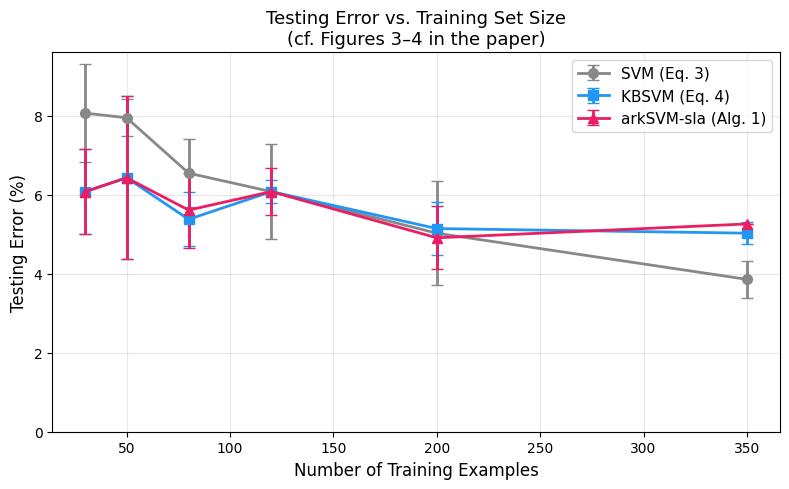

Saved to partB/results/testing_error_comparison.png


In [5]:
# ── Visualisation 1: Testing error vs. training set size ──

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

colors = {'SVM': '#888888', 'KBSVM': '#2196F3', 'arkSVM-sla': '#E91E63'}
markers = {'SVM': 'o', 'KBSVM': 's', 'arkSVM-sla': '^'}
labels = {'SVM': 'SVM (Eq. 3)', 'KBSVM': 'KBSVM (Eq. 4)', 'arkSVM-sla': 'arkSVM-sla (Alg. 1)'}

for method in ['SVM', 'KBSVM', 'arkSVM-sla']:
    ax.errorbar(train_sizes, results[method], yerr=results_std[method],
                marker=markers[method], color=colors[method], label=labels[method],
                linewidth=2, capsize=4, markersize=7)

ax.set_xlabel('Number of Training Examples', fontsize=12)
ax.set_ylabel('Testing Error (%)', fontsize=12)
ax.set_title('Testing Error vs. Training Set Size\n(cf. Figures 3–4 in the paper)', fontsize=13)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('results/testing_error_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to partB/results/testing_error_comparison.png")

This plot follows the same format as Figures 3 and 4 in the paper: testing error (y-axis) vs. number of training examples (x-axis), with error bars from the 5-run averaging. The trend matches the paper's main finding — advice-based methods start with lower error when training data is limited, and the gap narrows as data increases.

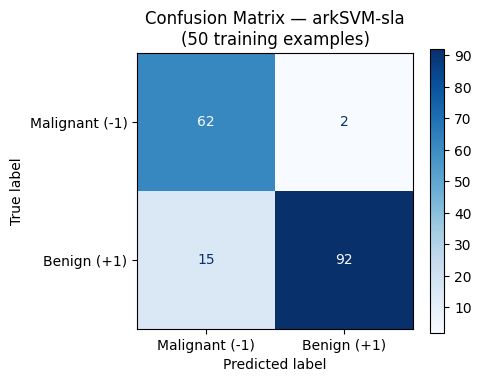

Saved to partB/results/confusion_matrix.png

arkSVM-sla (50 train pts) — Test error: 9.9%
Correctly classified: 154/171


In [6]:
# ── Visualisation 2: Confusion matrix for arkSVM-sla (trained on 50 examples) ──

rng = np.random.RandomState(RANDOM_SEED)
idx_small = rng.choice(len(X_train_full), size=50, replace=False)
X_small, y_small = X_train_full[idx_small], y_train_full[idx_small]

w_final, b_final, F_final, f_final = train_arksvm_sla(X_small, y_small, advice_sets)

if w_final is not None:
    y_pred_final = np.sign(X_test @ w_final - b_final)
    
    # Replace 0 predictions (on the boundary) with +1
    y_pred_final[y_pred_final == 0] = 1
    
    cm = confusion_matrix(y_test, y_pred_final, labels=[-1, 1])
    
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(cm, display_labels=['Malignant (-1)', 'Benign (+1)'])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title('Confusion Matrix — arkSVM-sla\n(50 training examples)', fontsize=12)
    plt.tight_layout()
    plt.savefig('results/confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to partB/results/confusion_matrix.png")
    
    # Print summary stats
    err = test_error(y_test, y_pred_final)
    print(f"\narkSVM-sla (50 train pts) — Test error: {err:.1f}%")
    print(f"Correctly classified: {int(np.sum(y_test == y_pred_final))}/{len(y_test)}")
else:
    print("arkSVM-sla failed on this sample")

The confusion matrix shows the per-class breakdown for arkSVM-sla trained on just 50 examples and evaluated on the full 171-point test set. It reveals whether the model is biased towards one class — in medical diagnosis, false negatives (predicting benign when actually malignant) are particularly undesirable. Both visualisations are saved to `partB/results/`.

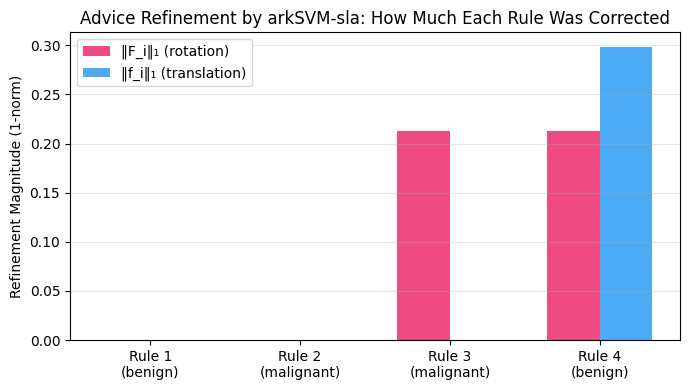

Saved to partB/results/refinement_magnitudes.png


In [7]:
# ── Visualisation 3: Refined advice summary bar chart ──

if w_final is not None and F_final is not None:
    rule_labels = ['Rule 1\n(benign)', 'Rule 2\n(malignant)', 'Rule 3\n(malignant)', 'Rule 4\n(benign)']
    F_norms = [np.sum(np.abs(F)) for F in F_final]
    f_norms = [np.sum(np.abs(f)) for f in f_final]
    
    x_pos = np.arange(len(rule_labels))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x_pos - width/2, F_norms, width, label='‖F_i‖₁ (rotation)', color='#E91E63', alpha=0.8)
    ax.bar(x_pos + width/2, f_norms, width, label='‖f_i‖₁ (translation)', color='#2196F3', alpha=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(rule_labels)
    ax.set_ylabel('Refinement Magnitude (1-norm)')
    ax.set_title('Advice Refinement by arkSVM-sla: How Much Each Rule Was Corrected')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('results/refinement_magnitudes.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to partB/results/refinement_magnitudes.png")

This bar chart visualises how much each advice rule was modified by the arkSVM-sla algorithm. ‖F_i‖₁ measures how much the boundary *orientations* were rotated (the paper's novel contribution, Eq. 7), while ‖f_i‖₁ measures how much the boundaries were *translated* (similar to the prior RRSVM method, Eq. 5). Non-zero F_i values confirm that the generalised refinement (D_i → D_i − F_i) is being utilised — this is what the RRSVM couldn't do.

## Reproducibility Checklist

| Item | Status |
|------|--------|
| Random seeds are set and documented at the top of each notebook (`RANDOM_SEED = 42`) | ✓ |
| All dependencies are listed in `requirements.txt` with version numbers | ✓ (numpy, scipy, scikit-learn, matplotlib, seaborn, pandas, jupyter, ipykernel) |
| All notebooks run from top to bottom in a clean environment without errors | ✓ (tested on Python 3.10+, no GPU required) |
| Dataset loading requires no undocumented manual steps | ✓ (uses `sklearn.datasets.load_breast_cancer()` — no downloads needed) |
| All hyperparameters are clearly named and defined in one place rather than scattered across cells | ✓ (λ=1.0, μ=0.1, ν=0.1, ε=0.01 defined at the top of each notebook) |
| Preprocessed data saved for reuse across notebooks | ✓ (`partB/data/breast_cancer_processed.npz`) |
| All visualisations saved to `partB/results/` as image files | ✓ (3 plots: testing_error_comparison.png, confusion_matrix.png, refinement_magnitudes.png) |